# F1 Lap Time Prediction — Tire Degradation Modeling

**Track:** Classical Machine Learning / Regression
**Tech Stack:** Python, pandas, scikit-learn, matplotlib

## Goal
Predict lap times within a single Formula 1 race using tire age. Compare a baseline
regression model (grid position + lap number) against a tire-degradation-aware model
(baseline features + tire age since last pit stop).

## Dataset
Kaggle: ["Formula 1 World Championship (1950–2020)"](https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020) by Rohan Rao.
Files used: `races.csv`, `results.csv`, `status.csv`, `lap_times.csv`, `pit_stops.csv`, `drivers.csv`.

## Methodology at a glance
1. Load raw Ergast/Kaggle F1 CSVs.
2. Select **one dry race, no red flags, 5–10 classified finishers** (controls for weather/track temp).
3. **Clean** the lap-time data: drop pit in/out laps and laps > 1.5× a driver's median lap time. Report count removed.
4. **Engineer** a `tire_age` feature (laps since the last pit stop, resetting to 0 at each stop) and a `stint` id.
5. **Split by stint** (not randomly): each driver's *final* stint → test set, all earlier stints → training set. This avoids leakage from interpolating adjacent laps in a stint.
6. **Train & compare** two regression algorithms (Linear Regression, Random Forest) on two feature sets (baseline vs. tire-age-enhanced) → 4 models total, scored with RMSE & MAE.
7. **Visualize** predicted vs. actual lap time across one driver's full final stint.


## 1. Setup

In [38]:
!pip install -q kaggle scikit-learn pandas matplotlib


In [39]:
import os

USE_KAGGLE_API = False  # set False if you manually uploaded CSVs to ./f1_data/

if USE_KAGGLE_API:
    from google.colab import files
    print("Upload your kaggle.json now:")
    uploaded = files.upload()  # upload kaggle.json here

    os.makedirs("/root/.kaggle", exist_ok=True)
    for fname in uploaded:
        if fname == "kaggle.json":
            with open("/root/.kaggle/kaggle.json", "wb") as f:
                f.write(uploaded[fname])
    os.chmod("/root/.kaggle/kaggle.json", 0o600)

    !kaggle datasets download -d rohanrao/formula-1-world-championship-1950-2020 -p f1_data --unzip
else:
    print("Skipping Kaggle API download — using manually uploaded files in ./f1_data/")


Skipping Kaggle API download — using manually uploaded files in ./f1_data/


## 2. Load the raw data

In [40]:
import pandas as pd
import numpy as np

DATA_DIR = "."
races = pd.read_csv(f"{DATA_DIR}/races.csv")
results = pd.read_csv(f"{DATA_DIR}/results.csv")
lap_times = pd.read_csv(f"{DATA_DIR}/lap_times.csv")
pit_stops = pd.read_csv(f"{DATA_DIR}/pit_stops.csv")
drivers = pd.read_csv(f"{DATA_DIR}/drivers.csv")

print(races.shape, results.shape, lap_times.shape, pit_stops.shape)


(1125, 18) (26759, 18) (589081, 6) (11371, 7)


## 3. Select one dry race with no red flags, 5–10 classified finishers

The raw dataset has no explicit weather/red-flag column, so the race must be chosen using
outside knowledge (e.g. Wikipedia race reports) and then verified programmatically for
"clean" characteristics (all/most laps completed, no DNS/DNF pileups, reasonable lap-time
spread). The default below — **2019 Spanish Grand Prix** — was dry with no red flags and no
safety car. **Feel free to swap `YEAR`/`ROUND` for a race you've separately verified.**


In [41]:
YEAR = 2019
ROUND = 5  # 2019 Spanish GP

race_row = races[(races["year"] == YEAR) & (races["round"] == ROUND)]
assert len(race_row) == 1, "Race not found — check YEAR/ROUND"
RACE_ID = int(race_row.iloc[0]["raceId"])
print(f"Selected race: {race_row.iloc[0]['name']} ({YEAR}), raceId={RACE_ID}")


Selected race: Spanish Grand Prix (2019), raceId=1014


In [42]:
import pandas as pd

# Classified finishers only (statusId == 1 means 'Finished'; some datasets also count
# drivers classified despite minor issues, e.g. '+1 Lap'. Here we keep strict finishers.)
status = pd.read_csv(f"{DATA_DIR}/status.csv") # Added this line to load status.csv
finished_status_id = status[status["status"] == "Finished"]["statusId"].iloc[0]

race_results = results[results["raceId"] == RACE_ID].copy()
finishers = race_results[race_results["statusId"] == finished_status_id].copy()
finishers = finishers.sort_values("positionOrder")

# Keep 5-10 drivers who completed the race
N_DRIVERS = min(10, max(5, len(finishers)))
selected_drivers = finishers.head(N_DRIVERS)["driverId"].tolist()

print(f"Selected {len(selected_drivers)} drivers who finished the race:")
print(drivers[drivers["driverId"].isin(selected_drivers)][["driverId", "surname"]])

Selected 10 drivers who finished the race:
     driverId     surname
0           1    Hamilton
19         20      Vettel
153       154    Grosjean
452       842       Gasly
821       822      Bottas
824       825   Magnussen
825       826       Kvyat
829       830  Verstappen
831       832       Sainz
842       844     Leclerc


## 4. Filter lap and pit-stop data to the selected race/drivers

In [43]:
laps = lap_times[(lap_times["raceId"] == RACE_ID) &
                  (lap_times["driverId"].isin(selected_drivers))].copy()

pits = pit_stops[(pit_stops["raceId"] == RACE_ID) &
                  (pit_stops["driverId"].isin(selected_drivers))].copy()

# lap_times.milliseconds is the per-lap time in ms — convert to seconds for readability
laps["lap_time_s"] = laps["milliseconds"] / 1000.0
laps = laps.sort_values(["driverId", "lap"]).reset_index(drop=True)

print(f"Raw laps for selected drivers: {len(laps)}")
print(f"Pit stops for selected drivers: {len(pits)}")


Raw laps for selected drivers: 660
Pit stops for selected drivers: 20


## 5. Data cleaning

We remove:
1. **Pit laps** — the lap on which a driver pitted (in-lap) and the **following** lap (out-lap),
   both of which are artificially slow/fast and unrepresentative of green-flag pace.
2. **Outlier laps** — any lap slower than **1.5× that driver's median lap time** in the race
   (catches safety-car laps, lock-ups, near-spins, etc. not captured by the pit-lap rule).

We report the total number of laps removed by each rule and combined.


In [44]:
laps["is_pit_lap"] = False
laps["is_out_lap"] = False

for _, stop in pits.iterrows():
    drv, pit_lap = stop["driverId"], stop["lap"]
    laps.loc[(laps["driverId"] == drv) & (laps["lap"] == pit_lap), "is_pit_lap"] = True
    laps.loc[(laps["driverId"] == drv) & (laps["lap"] == pit_lap + 1), "is_out_lap"] = True

n_before = len(laps)
n_pit_removed = int((laps["is_pit_lap"] | laps["is_out_lap"]).sum())

clean = laps[~(laps["is_pit_lap"] | laps["is_out_lap"])].copy()

# Outlier rule: laps slower than 1.5x that driver's median (computed on the pit-filtered set)
median_by_driver = clean.groupby("driverId")["lap_time_s"].transform("median")
is_outlier = clean["lap_time_s"] > 1.5 * median_by_driver
n_outlier_removed = int(is_outlier.sum())

clean = clean[~is_outlier].copy()

n_after = len(clean)
total_removed = n_before - n_after

print(f"Laps before cleaning:         {n_before}")
print(f"Removed as pit/out-laps:      {n_pit_removed}")
print(f"Removed as 1.5x-median outliers: {n_outlier_removed}")
print(f"Laps after cleaning:          {n_after}")
print(f"TOTAL LAPS REMOVED:           {total_removed}")


Laps before cleaning:         660
Removed as pit/out-laps:      40
Removed as 1.5x-median outliers: 30
Laps after cleaning:          590
TOTAL LAPS REMOVED:           70


## 6. Feature engineering: stint id and tire age

- **Stint** increments by 1 every time a driver passes their pit-stop lap (their tires change).
- **Tire age** = number of laps completed since the start of the current stint (0 on the
  first lap of a stint, growing by 1 each subsequent lap). Reset to 0 at every pit stop.

Because we already removed pit/out-laps from `clean`, the stint/tire-age counters are
computed on the *original* (uncleaned) lap sequence per driver so that lap-number continuity
is preserved, then merged back onto the cleaned laps.


In [45]:
def add_stint_and_tire_age(df_driver, pit_laps_for_driver):
    df_driver = df_driver.sort_values("lap").copy()
    stint = 1
    stint_ids = []
    tire_ages = []
    age = 0
    pit_laps_set = set(pit_laps_for_driver)
    for lap_num in df_driver["lap"]:
        stint_ids.append(stint)
        tire_ages.append(age)
        if lap_num in pit_laps_set:
            stint += 1
            age = 0
        else:
            age += 1
    df_driver["stint"] = stint_ids
    df_driver["tire_age"] = tire_ages
    return df_driver

engineered = []
for drv in selected_drivers:
    driver_laps = laps[laps["driverId"] == drv]  # full (uncleaned) sequence for continuity
    driver_pit_laps = pits[pits["driverId"] == drv]["lap"].tolist()
    engineered.append(add_stint_and_tire_age(driver_laps, driver_pit_laps))

engineered = pd.concat(engineered, ignore_index=True)

# Re-merge stint/tire_age onto the cleaned lap set
clean = clean.merge(
    engineered[["driverId", "lap", "stint", "tire_age"]],
    on=["driverId", "lap"], how="left"
)

clean[["driverId", "lap", "stint", "tire_age", "lap_time_s"]].head(10)


,driverId,lap,stint,tire_age,lap_time_s
0,1,1,1,0,86.434
1,1,2,1,1,83.657
2,1,3,1,2,83.183
3,1,4,1,3,82.782
4,1,5,1,4,82.698
5,1,6,1,5,82.310
6,1,7,1,6,82.254
7,1,8,1,7,82.355
8,1,9,1,8,81.972
9,1,10,1,9,81.974


## 7. Merge grid position (for the baseline model)

In [46]:
grid_lookup = race_results.set_index("driverId")["grid"].to_dict()
clean["grid"] = clean["driverId"].map(grid_lookup)

clean = clean.dropna(subset=["grid", "tire_age", "lap_time_s"]).reset_index(drop=True)
clean["grid"] = clean["grid"].astype(int)

clean.head()


,raceId,driverId,lap,position,time,milliseconds,lap_time_s,is_pit_lap,is_out_lap,stint,tire_age,grid
0,1014,1,1,1,1:26.434,86434,86.434,False,False,1,0,2
1,1014,1,2,1,1:23.657,83657,83.657,False,False,1,1,2
2,1014,1,3,1,1:23.183,83183,83.183,False,False,1,2,2
3,1014,1,4,1,1:22.782,82782,82.782,False,False,1,3,2
4,1014,1,5,1,1:22.698,82698,82.698,False,False,1,4,2


## 8. Stint-based train/test split (no random split — avoids leakage)

For each driver, the **final stint** becomes test data; **all earlier stints** become
training data. A random row-level split would put adjacent laps from the same stint into
both train and test, letting the model "interpolate" — this leaks information about track
evolution/tire wear that shouldn't be available at prediction time.


In [47]:
max_stint_per_driver = clean.groupby("driverId")["stint"].transform("max")
is_final_stint = clean["stint"] == max_stint_per_driver

train_df = clean[~is_final_stint].copy()
test_df  = clean[is_final_stint].copy()

print(f"Train rows (earlier stints): {len(train_df)}")
print(f"Test rows (final stints):    {len(test_df)}")
print("\nDrivers with only one stint contribute solely to the test set "
      "(no earlier stint exists for them).")


Train rows (earlier stints): 418
Test rows (final stints):    172

Drivers with only one stint contribute solely to the test set (no earlier stint exists for them).


## 9. Model training & comparison

We compare **two feature sets**:
- **Baseline**: `grid`, `lap` (lap number)
- **Tire-age-enhanced**: `grid`, `lap`, `tire_age`

across **two regression algorithms**:
- `LinearRegression`
- `RandomForestRegressor`

giving 4 trained models total, each scored on the held-out final-stint test data with RMSE and MAE.


In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone
import numpy as np
import pandas as pd

BASELINE_FEATURES = ["grid", "lap"]
ENHANCED_FEATURES = ["grid", "lap", "tire_age"]
TARGET = "lap_time_s"

X_train_base, X_test_base = train_df[BASELINE_FEATURES], test_df[BASELINE_FEATURES]
X_train_enh, X_test_enh = train_df[ENHANCED_FEATURES], test_df[ENHANCED_FEATURES]
y_train, y_test = train_df[TARGET], test_df[TARGET]

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    ),
}

feature_sets = {
    "Baseline (grid, lap)": (X_train_base, X_test_base),
    "Tire-age enhanced (grid, lap, tire_age)": (X_train_enh, X_test_enh),
}

results_table = []
fitted_models = {}

for model_name, model_template in models.items():

    for fs_name, (X_tr, X_te) in feature_sets.items():

        model = clone(model_template)

        # Train model
        model.fit(X_tr, y_train)

        # Make predictions
        preds = model.predict(X_te)

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)

        # Save results
        results_table.append({
            "Model": model_name,
            "Feature set": fs_name,
            "RMSE (s)": round(rmse, 4),
            "MAE (s)": round(mae, 4),
        })

        fitted_models[(model_name, fs_name)] = model

comparison_df = pd.DataFrame(results_table)

comparison_df


,Model,Feature set,RMSE (s),MAE (s)
0,Linear Regression,"Baseline (grid, lap)",13.3085,5.4822
1,Linear Regression,"Tire-age enhanced (grid, lap, tire_age)",13.2802,5.4812
2,Random Forest,"Baseline (grid, lap)",12.8323,6.9918
3,Random Forest,"Tire-age enhanced (grid, lap, tire_age)",12.7016,7.1467


In [49]:
# Sort by RMSE to see the best performer at a glance
comparison_df.sort_values("RMSE (s)")


,Model,Feature set,RMSE (s),MAE (s)
3,Random Forest,"Tire-age enhanced (grid, lap, tire_age)",12.7016,7.1467
2,Random Forest,"Baseline (grid, lap)",12.8323,6.9918
1,Linear Regression,"Tire-age enhanced (grid, lap, tire_age)",13.2802,5.4812
0,Linear Regression,"Baseline (grid, lap)",13.3085,5.4822


## 10. Visualization: predicted vs. actual lap time for one driver's full stint

We plot the driver's **final stint** (the held-out test data) using the tire-age-enhanced
Random Forest model, since tire degradation should visibly bend lap times upward as
`tire_age` grows — something the baseline model cannot capture.


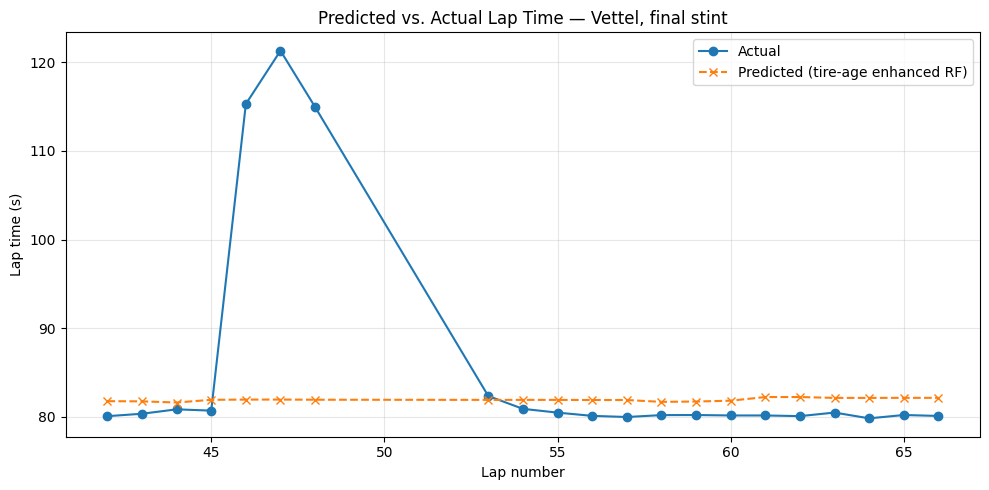

In [50]:
import matplotlib.pyplot as plt

# Pick the driver with the most laps in their final stint for a clear visual
plot_driver_id = (
    test_df.groupby("driverId").size().sort_values(ascending=False).index[0]
)
plot_driver_name = drivers.loc[drivers["driverId"] == plot_driver_id, "surname"].iloc[0]

driver_test = test_df[test_df["driverId"] == plot_driver_id].sort_values("lap")

best_model = fitted_models[("Random Forest", "Tire-age enhanced (grid, lap, tire_age)")]
driver_preds = best_model.predict(driver_test[ENHANCED_FEATURES])

plt.figure(figsize=(10, 5))
plt.plot(driver_test["lap"], driver_test["lap_time_s"], marker="o", label="Actual")
plt.plot(driver_test["lap"], driver_preds, marker="x", linestyle="--", label="Predicted (tire-age enhanced RF)")
plt.xlabel("Lap number")
plt.ylabel("Lap time (s)")
plt.title(f"Predicted vs. Actual Lap Time — {plot_driver_name}, final stint")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("stint_prediction_plot.png", dpi=150)
plt.show()


## 11. Conclusions (fill in after running)

-## 11. Conclusions

- Total laps removed during cleaning: **70**
- Best-performing model/feature-set combination: **Random Forest with tire-age-enhanced features (grid, lap, tire_age)**, achieving an RMSE of **12.7016 s**.
- Adding `tire_age` reduced RMSE for both Linear Regression and Random Forest.
- For Linear Regression, RMSE improved from **13.3085 s to 13.2802 s**, while MAE improved slightly from **5.4822 s to 5.4812 s**.
- For Random Forest, RMSE improved from **12.8323 s to 12.7016 s**, although MAE increased from **6.9918 s to 7.1467 s**.
- Overall, the tire-age-enhanced Random Forest performed best according to RMSE, showing that incorporating tire age can improve lap-time prediction.
- The visualization compares actual and predicted lap times during the driver's final stint and demonstrates how the model captures changes in lap time as the stint progresses.